# Logistic Regression

---

## 1️⃣ What is Logistic Regression?

Logistic Regression is a supervised classification algorithm used to predict the probability of a binary outcome (0 or 1).

It estimates:

$$
P(y=1 \mid x) = h_\theta(x)
$$

The output is always between **0 and 1**, making it suitable for probability estimation.

---

## 2️⃣ Hypothesis Function

Logistic regression applies the sigmoid function to a linear model.

$$
h_\theta(x) = \sigma(\theta^T x)
$$

Where:

$$
z = \theta^T x = \theta_0 + \theta_1 x_1 + \dots + \theta_n x_n
$$

---

## 3️⃣ Sigmoid Function

The sigmoid (logistic) function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### Properties:

- Range: (0, 1)
- Smooth and differentiable
- Converts linear output into probability

Derivative of sigmoid:

$$
\frac{d}{dz}\sigma(z) = \sigma(z)(1 - \sigma(z))
$$

---

# Logistic Regression – Loss and Cost Function

---

## 4️⃣ Predicted Output (ŷ)

In Logistic Regression, the predicted probability is denoted as ŷ (y hat).

$$
\hat{y} = \sigma(z)
$$

Where:

$$
z = \theta^T x
$$

And the sigmoid function is:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

So the final prediction formula is:

$$
\hat{y} = \frac{1}{1 + e^{-\theta^T x}}
$$

---

## 5️⃣ Loss Function (For One Training Example)

The loss function (Binary Cross-Entropy) for a single example is:

$$
L(\hat{y}, y) =
- \left[
y \log(\hat{y}) + (1 - y)\log(1 - \hat{y})
\right]
$$

Where:

- $y$ = actual label (0 or 1)
- $\hat{y}$ = predicted probability

---

## 6️⃣ Cost Function (For Entire Dataset)

The cost function is the average loss over all training examples:

$$
J(\theta) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y^{(i)} \log(\hat{y}^{(i)})
+
(1 - y^{(i)}) \log(1 - \hat{y}^{(i)})
\right]
$$

Where:

- $m$ = number of training examples
- $\hat{y}^{(i)}$ = predicted probability for example $i$

---

## 🔎 Important Notes

- Loss function → error for **one** example
- Cost function → average loss over **all** examples
- ŷ is computed using the **sigmoid function**

This cost function is **convex**, which guarantees a global minimum.

---

## 7️⃣ Gradient Descent for Logistic Regression

### Step 1: Gradient of Cost Function

$$
\frac{\partial J(\theta)}{\partial \theta_j}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(
h_\theta(x^{(i)}) - y^{(i)}
\right)
x_j^{(i)}
$$

---

### Step 2: Gradient Descent Update Rule

$$
\theta_j :=
\theta_j
-
\alpha
\frac{1}{m}
\sum_{i=1}^{m}
\left(
h_\theta(x^{(i)}) - y^{(i)}
\right)
x_j^{(i)}
$$

Where:

- $\alpha$ = learning rate

---

## Vectorized Form (Recommended Implementation)

Gradient:

$$
\nabla J(\theta) = \frac{1}{m} X^T (h_\theta - y)
$$

Update rule:

$$
\theta := \theta - \alpha \frac{1}{m} X^T (h_\theta - y)
$$

---

## 8️⃣ Decision Rule

$$
\hat{y} =
\begin{cases}
1 & \text{if } h_\theta(x) \ge 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

Decision boundary occurs when:

$$
\theta^T x = 0
$$

---

# 🔑 Key Takeaways

- Logistic Regression outputs probabilities.
- Uses Sigmoid activation.
- Uses Binary Cross-Entropy loss.
- Cost function is convex.
- Gradient looks similar to Linear Regression, but hypothesis is different.


# Workflow of the Logistic Regression Model

## Step 1:

Set **learning rate** and **number of iterations**.  
Initialize random weight and bias values.

## Step 2:

Build the Logistic Regression function (sigmoid function).

## Step 3:

Update the parameters using gradient descent.

After training, we obtain the best model (optimal weight and bias values) where the cost function is minimized.

## Step 4:

Build the `predict` function to determine the class of a data point.


In [21]:
import numpy as np


class LogisticRegression:

    def __init__(self, learning_rate=0.01, iterations=1000) -> None:
        self.learning_rate = learning_rate
        self.iterations = iterations

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.m, self.n = X.shape

        # initiate weight and bias
        self.w = np.zeros(self.n)
        self.b = 0
        self.X = X
        self.y = y

        for i in range(self.iterations):
            self.update_weights()

    def update_weights(self):
        net_inputs = np.dot(self.X, self.w) + self.b
        y_hat = self._sigmoid(net_inputs)

        # derivatives

        dw = (1 / self.m) * np.dot(self.X.T, (y_hat - self.y))

        db = (1 / self.m) * np.sum(y_hat - self.y)

        # updating the weight and bias
        self.w = self.w - self.learning_rate * dw
        self.b = self.b - self.learning_rate * db

    def predict(self, X):
        new_net_inputs = np.dot(X, self.w) + self.b
        Y_pred = self._sigmoid(new_net_inputs)
        Y_pred = np.where(Y_pred > 0.5, 1, 0)
        return Y_pred

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [23]:
diabetes_dataset = pd.read_csv(
    r"C:\Users\USER\ipnyb files\Machine Learning\Classification\Datasets\diabetes.csv"
)

In [24]:
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
diabetes_dataset.shape

(768, 9)

In [26]:
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [27]:
diabetes_dataset["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [28]:
diabetes_dataset.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [29]:
features = diabetes_dataset.drop(columns="Outcome", axis=1)
target = diabetes_dataset["Outcome"]

In [30]:
scaler = StandardScaler()
standardized_data = scaler.fit_transform(features)
features = standardized_data
features

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.33, random_state=42
)

In [32]:
classifier = LogisticRegression(learning_rate=0.01, iterations=1000)
classifier.fit(X_train, y_train)

In [33]:
y_train_pred = classifier.predict(X_train)
training_data_accuracy = accuracy_score(y_train, y_train_pred)
training_data_accuracy

0.7782101167315175

In [34]:
y_test_pred = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_test, y_test_pred)
test_data_accuracy

0.7322834645669292

In [35]:
from sklearn.linear_model import LogisticRegression

sk_classifier = LogisticRegression()
sk_classifier.fit(X_train, y_train)

y_train_pred = sk_classifier.predict(X_train)
training_data_accuracy = accuracy_score(y_train, y_train_pred)
training_data_accuracy

0.7801556420233463

In [36]:
y_test_pred = sk_classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_test, y_test_pred)
test_data_accuracy

0.7401574803149606

# Iris Dataset


Build a classifier to detect the Iris-Virginica type based only on the petal
width feature


In [37]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [38]:
X = iris.data[:, 3:]
y = (iris.target == 2).astype(int)


In [39]:
log_reg = LogisticRegression()
log_reg.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


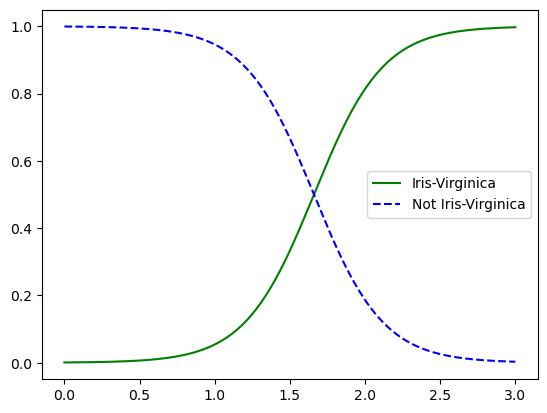

In [40]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
plt.plot(X_new, y_proba[:, 1], "g-", label="Iris-Virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label="Not Iris-Virginica")
plt.legend()
plt.show()

# Softmax Regression (Multiclass Logistic Regression)

---

## 1️⃣ What is Softmax Regression?

Softmax Regression is an extension of Logistic Regression used for **multiclass classification** (more than two classes).

Instead of predicting a single probability (as in binary logistic regression), it predicts the probability for **each class simultaneously**.

It is also called:

- Multiclass Logistic Regression
- Softmax Classifier

---

## 2️⃣ When Do We Use It?

Use Softmax Regression when:

- The target has **3 or more classes**
- Classes are **mutually exclusive**
- We want class probabilities

---

# Mathematical Steps in Softmax Regression

Assume:

- $m$ = number of samples
- $n$ = number of features
- $K$ = number of classes

Input feature vector:

$$
x \in \mathbb{R}^n
$$

Each class $k$ has:

$$
w_k \in \mathbb{R}^n, \quad b_k \in \mathbb{R}
$$

---

## 3️⃣ Step 1: Compute Class Scores (Linear Step)

For each class $k$, compute a score:

$$
s_k(x) = w_k^T x + b_k
$$

This is the same structure as Linear Regression.

Vectorized form:

$$
S = XW + b
$$

Where:

- $X$ → $(m \times n)$
- $W$ → $(n \times K)$
- $S$ → $(m \times K)$

Each row of $S$ contains scores for all classes.

---

## 4️⃣ Step 2: Apply Softmax Function

Convert scores into probabilities:

$$
P(y = k \mid x) =
\frac{e^{s_k(x)}}{\sum_{j=1}^{K} e^{s_j(x)}}
$$

This ensures:

- All probabilities are positive
- Probabilities sum to 1

$$
\sum_{k=1}^{K} P(y = k \mid x) = 1
$$

---

## 5️⃣ Step 3: Prediction Rule

Predicted class:

$$
\hat{y} = \arg\max_k P(y = k \mid x)
$$

Choose the class with the highest probability.

---

## 6️⃣ Step 4: Loss Function (Multiclass Cross-Entropy)

For one sample:

$$
L = - \sum_{k=1}^{K} y_k \log(P(y = k \mid x))
$$

Where:

- $y_k = 1$ if correct class
- $y_k = 0$ otherwise (one-hot encoding)

For entire dataset:

$$
J(W) =
-\frac{1}{m}
\sum_{i=1}^{m}
\sum_{k=1}^{K}
y_k^{(i)}
\log P(y = k \mid x^{(i)})
$$

---

## 7️⃣ Step 5: Gradient (Vectorized Form)

The gradient of the cost function:

$$
\nabla_W J =
\frac{1}{m}
X^T (P - Y)
$$

Where:

- $P$ = predicted probability matrix $(m \times K)$
- $Y$ = one-hot encoded true labels $(m \times K)$

---

## 8️⃣ Step 6: Update Rule (Gradient Descent)

$$
W := W - \alpha \nabla_W J
$$

Where:

- $\alpha$ = learning rate

---

# 🔑 Summary of the Algorithm

1. Compute linear scores for each class.
2. Apply softmax to get probabilities.
3. Compute cross-entropy loss.
4. Compute gradient.
5. Update weights.
6. Repeat until convergence.

---

# Key Differences from Binary Logistic Regression

| Binary Logistic    | Softmax Regression          |
| ------------------ | --------------------------- |
| 2 classes          | 3+ classes                  |
| Sigmoid function   | Softmax function            |
| Single probability | Probability vector          |
| One weight vector  | One weight vector per class |

---

# Final Intuition

Softmax Regression:

- Computes a score for each class
- Converts scores into probabilities
- Picks the class with highest probability
- Learns by minimizing cross-entropy loss


In [42]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs", C=10, random_state=42)
softmax_reg.fit(X, y)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [43]:
softmax_reg.predict([[5, 2]])

array([2])